# TELECOMMUNICATION NETWORK OPTIMIZATION: A MACHINE LEARNING APPROACH
### Khidir Ismail Ramadhan
### Student Number: 083303
#### This project presents a pioneering machine learning approach to network optimization, using geospatial clustering to enhance the quality and reach of network services. By applying advanced analytical techniques to geospatial data, including site names, latitudes, longitudes, and azimuth orientations, it looks to unravel complex network dynamics and find strategic opportunities for infrastructure enhancement.

1. [Data Pre-preocessing](#preprocessing)  
    1.1 [Installing Packages and Libraries](#install)  
    1.2 [Data Description](#descriptionandimport)  
    1.3 [Data Exploration and Cleaning](#exploreandclean)   
    1.4 [Normalization](#normalization) 
2. [Feature Engineering](#featureeng)  
    2.1 [Explaratory Data Analysis (EDA)](#eda)  
    2.2 [Visualization](#viz)  
    2.3 [Calculations](#calc) 
3. [Modelling](#modelling)  
    3.1 [Elbow Method](#elbow)  
    3.2 [Training and Fitting](#trainandfit)  
    3.3 [Evaluation](#evaluation) 
3. [Deployment](#deployment) 

# 1. Data Preprocessing <a name="preprocessing"></a>
## 1.1 Installing Packages and Libraries <a name="install"></a>

In [5]:
!pip3 install pandas
!pip3 install numpy
!pip3 install geopy
!pip3 install tqdm
!pip3 install openpyxl
!pip3 install missingno
!pip3 install folium pandas


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [6]:
#import necessary libraries
import pandas as pd
import numpy as np
import missingno as mn
from math import *
from numpy import *
from geopy.distance import geodesic
import datetime
from tqdm import tqdm
import folium

## 1.2 Data Description and Import <a name="descriptionandimport"></a>

This Jupyter notebook provides a detailed analysis of telecommunications sites using geospatial data for Cellname1 and Cellname2. The dataset includes latitude (lat), longitude (long), and azimuth values for both cells. This information is crucial for optimizing the placement and orientation of cell towers, enhancing network coverage, and improving communication quality in the telecommunications industry.

Key Terminology

Latitude (Lat): Latitude is the angular distance of a location north or south of the Earth's equator, measured in degrees. It indicates a site's north-south position on the globe.

Longitude (Long): Longitude is the angular distance of a location east or west of the prime meridian, also measured in degrees. It indicates a site's east-west position on the globe.

Azimuth: Azimuth is the compass direction from which the signal is transmitted from a cell tower. It is measured in degrees clockwise from true north. Azimuth angles are crucial for determining the direction in which antennas should be pointed to establish optimal connections.

In [7]:
#Read the source file, should contain source cell id target cell id azimuths 
parameters_file=pd.read_excel("https://raw.githubusercontent.com/khidwiser/MSC-DSA-FINAL-PROJECT/main/Neighbor_Data.xlsx")
parameters_file.head()

,Cellname1,Source LAT,Source LONG,Source Azimuth,CellName2,Target LAT,Target LONG,Target Azimuth
0,BMT0011,-0.780656,35.3374,100.0,BMT0151,-0.789185,35.398700,0.0
1,BMT0011,-0.780656,35.3374,100.0,BMT0241,-0.785847,35.297634,90.0
2,BMT0011,-0.780656,35.3374,100.0,BMT0231,-0.739003,35.381522,0.0
3,BMT0011,-0.780656,35.3374,100.0,BMT0261,-0.744234,35.352024,30.0
4,BMT0011,-0.780656,35.3374,100.0,BMT0251,-0.786775,35.338931,30.0


## 1.3 Data Exploration and Cleaning <a name="exploreandclean"></a>

In [8]:
#data types look out for object and float64 as they may contain missing values
parameters_file.dtypes

Cellname1          object
Source LAT        float64
Source LONG       float64
Source Azimuth    float64
CellName2          object
Target LAT        float64
Target LONG       float64
Target Azimuth    float64
dtype: object

In [9]:
parameters_file.shape

(261328, 8)

In [10]:
# Missing values
parameters_file.isna()

,Cellname1,Source LAT,Source LONG,Source Azimuth,CellName2,Target LAT,Target LONG,Target Azimuth
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
261323,False,True,True,True,False,True,True,True
261324,False,True,True,True,False,True,True,True
261325,False,True,True,True,False,True,True,True
261326,False,False,False,False,False,False,False,False


In [11]:
#sum of missing values
parameters_file.isna().sum()

Cellname1            0
Source LAT        6308
Source LONG       6308
Source Azimuth    6308
CellName2            0
Target LAT        7610
Target LONG       7610
Target Azimuth    7610
dtype: int64

In [12]:
#Percentage of column missing values
parameters_file.isna().mean() * 100

Cellname1         0.000000
Source LAT        2.413825
Source LONG       2.413825
Source Azimuth    2.413825
CellName2         0.000000
Target LAT        2.912049
Target LONG       2.912049
Target Azimuth    2.912049
dtype: float64

<Axes: >

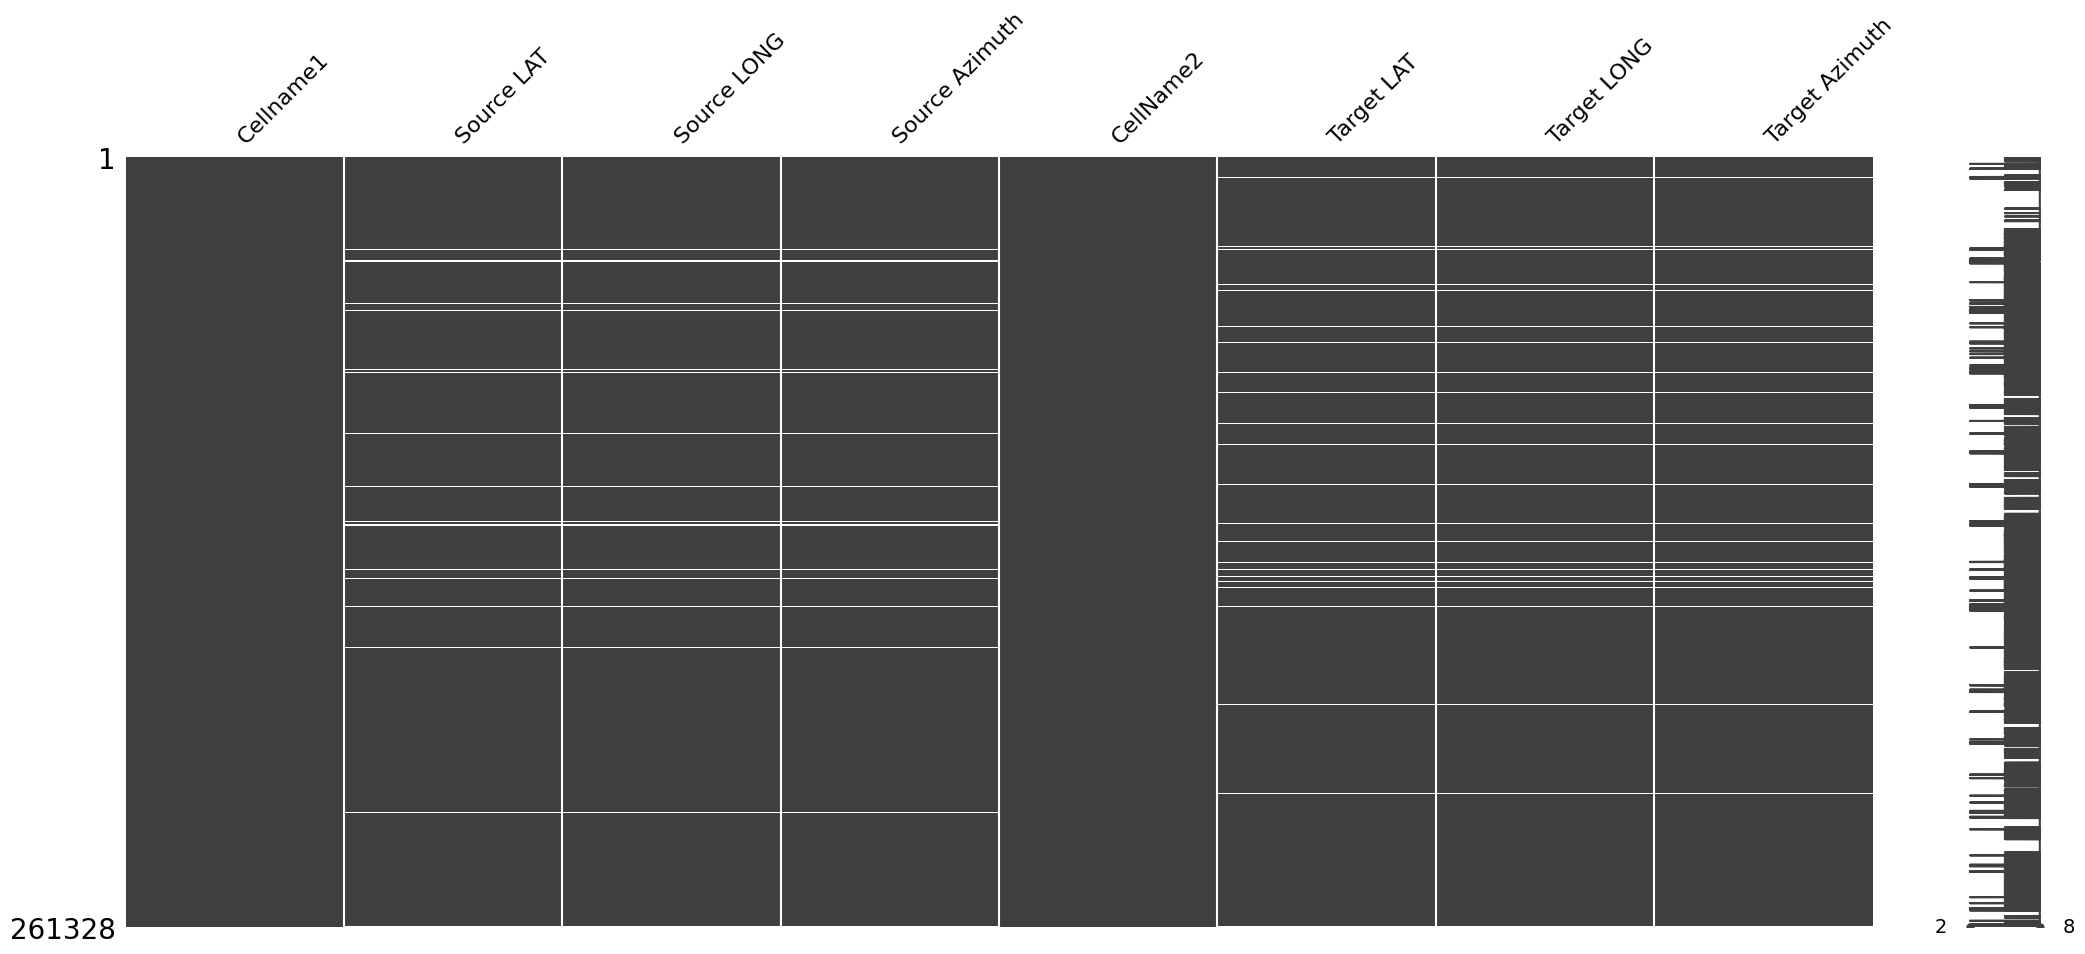

In [13]:
mn.matrix(parameters_file)

In [14]:
#group by source cell name this will be used later 
groups = parameters_file.groupby(['Cellname1','CellName2']).groups

In [15]:
#cleaning the data where we have null values
parameters_file = parameters_file.dropna(subset=['Target Azimuth', 'Source Azimuth', 'Source LAT', 'Source LONG', 'Target LAT', 'Target LONG'])

<Axes: >

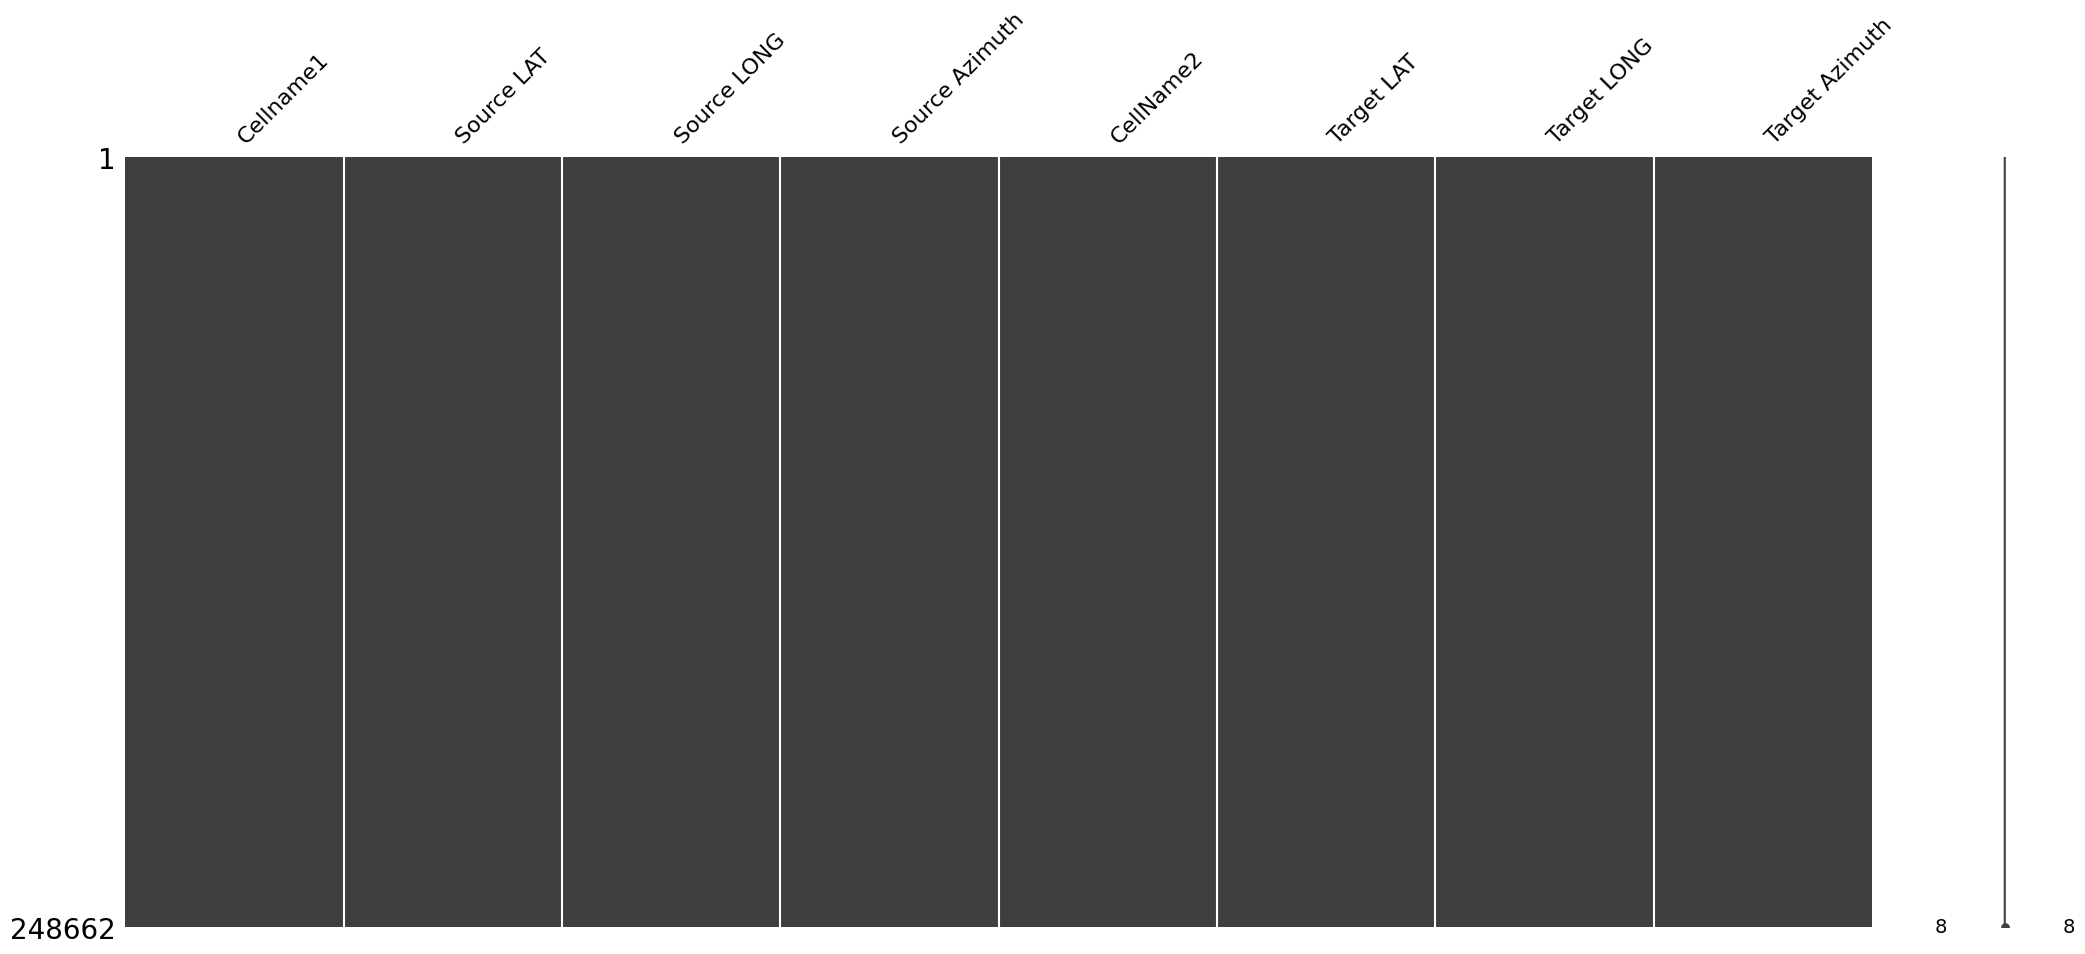

In [16]:
mn.matrix(parameters_file)

In [17]:
#sum of missing values
parameters_file.isna().sum()

Cellname1         0
Source LAT        0
Source LONG       0
Source Azimuth    0
CellName2         0
Target LAT        0
Target LONG       0
Target Azimuth    0
dtype: int64

In [18]:
#Percentage of column missing values
parameters_file.isna().mean() * 100

Cellname1         0.0
Source LAT        0.0
Source LONG       0.0
Source Azimuth    0.0
CellName2         0.0
Target LAT        0.0
Target LONG       0.0
Target Azimuth    0.0
dtype: float64

## 1.4. Normalization <a name="normalization"></a>

In [19]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import pandas as pd


# Selecting only the numerical columns for normalization
numerical_columns = ['Source LAT', 'Source LONG', 'Source Azimuth', 'Target LAT', 'Target LONG', 'Target Azimuth']

# Creating a MinMaxScaler object
scaler = MinMaxScaler()

# Fit and transform the numerical columns
parameters_file[numerical_columns] = scaler.fit_transform(parameters_file[numerical_columns])

# Displaying the normalized DataFrame
print(parameters_file)


       Cellname1  Source LAT  Source LONG  Source Azimuth CellName2  \
0        BMT0011    0.422757     0.177835        0.279778   BMT0151   
1        BMT0011    0.422757     0.177835        0.279778   BMT0241   
2        BMT0011    0.422757     0.177835        0.279778   BMT0231   
3        BMT0011    0.422757     0.177835        0.279778   BMT0261   
4        BMT0011    0.422757     0.177835        0.279778   BMT0251   
...          ...         ...          ...             ...       ...   
261253   NOK046C    0.387809     0.244357        0.916898   NOK044A   
261254   MDI045A    0.157373     0.778850        0.085873   MDI050B   
261255   MDI050B    0.157168     0.780271        0.584488   MDI045A   
261279   MSA174A    0.071333     0.731329        0.058172   MSA247A   
261326   MSA247A    0.070621     0.729173        0.155125   MSA174A   

        Target LAT  Target LONG  Target Azimuth  
0         0.421827     0.185565        0.002770  
1         0.422191     0.172820        0.252078

The provided code snippet performs data normalization using Min-Max scaling on numerical columns in a DataFrame. Here's a breakdown of the process:

1. **Data Selection**:
   - Only the numerical columns of interest are selected for normalization. These columns include 'Source LAT', 'Source LONG', 'Source Azimuth', 'Target LAT', 'Target LONG', and 'Target Azimuth'.

2. **Normalization**:
   - A MinMaxScaler object is created, which scales the data to a specified range (usually between 0 and 1).
   - The scaler is then fitted to the selected numerical columns using the `fit_transform()` method. This process computes the minimum and maximum values of each column and scales the data accordingly.
   - The original numerical columns in the DataFrame are replaced with their normalized values.

3. **Output**:
   - The normalized DataFrame is printed to the console using `print(parameters_file)`, allowing for inspection of the transformed data.

Overall, this preprocessing step ensures that all numerical features are on a consistent scale, which can be important for certain machine learning algorithms that are sensitive to the scale of input features.


# 2. Feature Engineering <a name="featureeng"></a>
## 2.1 Exploratory Data Analysis (EDA) <a name="eda"></a>

In [20]:
# Load a random sample of the data
sample_data = parameters_file.sample(n=200)

# Folium map centered around the mean latitude and longitude of source locations
map_center = [sample_data[['Source LAT', 'Source LONG']].mean().mean(), sample_data[['Source LAT', 'Source LONG']].mean().mean()]
mymap = folium.Map(location=map_center, zoom_start=12)

# Add source markers to the map
for index, row in sample_data.iterrows():
    folium.Marker([row['Source LAT'], row['Source LONG']], popup=row['Cellname1']).add_to(mymap)

# Add target markers to the map
for index, row in sample_data.iterrows():
    folium.Marker([row['Target LAT'], row['Target LONG']], popup=row['CellName2']).add_to(mymap)

# Display the map
mymap

In [21]:
# Display summary statistics of numerical variables
print(parameters_file.describe())

          Source LAT    Source LONG  Source Azimuth     Target LAT  \
count  248662.000000  248662.000000   248662.000000  248662.000000   
mean        0.406348       0.339788        0.491732       0.406311   
std         0.136240       0.182556        0.293359       0.136205   
min         0.000000       0.000000        0.000000       0.000000   
25%         0.366767       0.175954        0.252078       0.366772   
50%         0.392403       0.363089        0.515235       0.392403   
75%         0.493777       0.395803        0.750693       0.493957   
max         1.000000       1.000000        1.000000       1.000000   

         Target LONG  Target Azimuth  
count  248662.000000   248662.000000  
mean        0.339818        0.491008  
std         0.182703        0.293451  
min         0.000000        0.000000  
25%         0.175762        0.252078  
50%         0.363152        0.501385  
75%         0.395925        0.750693  
max         1.000000        1.000000  


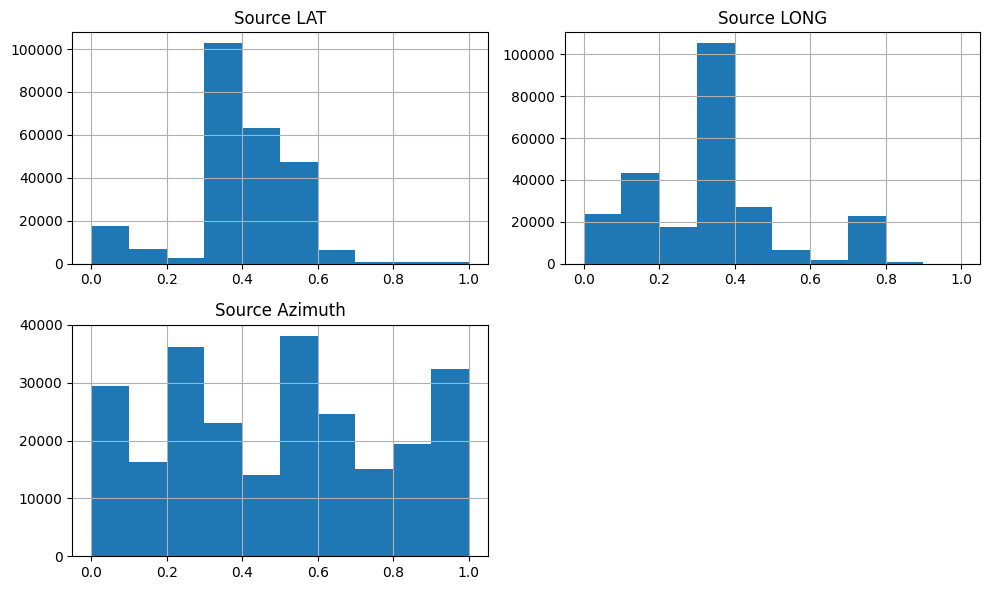

In [22]:
import matplotlib.pyplot as plt

# Plot histograms of numerical variables
parameters_file[['Source LAT', 'Source LONG', 'Source Azimuth']].hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

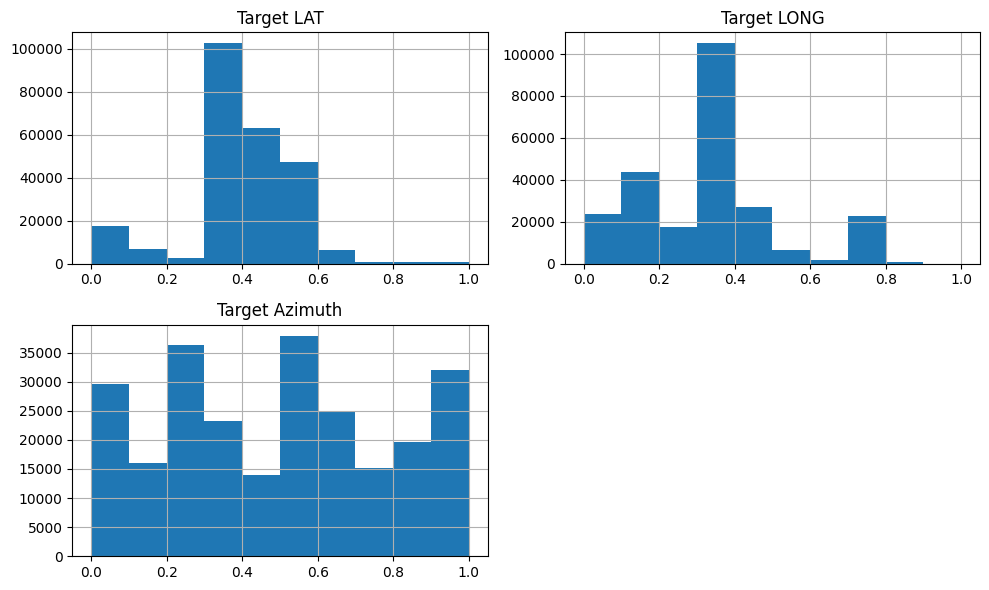

In [23]:
import matplotlib.pyplot as plt

# Plot histograms of numerical variables
parameters_file[['Target LAT', 'Target LONG', 'Target Azimuth']].hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

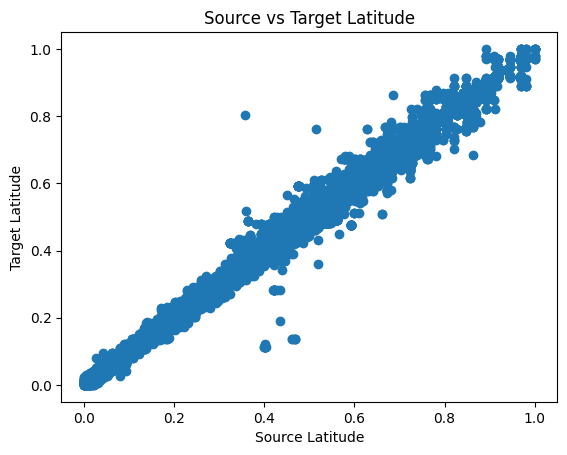

In [24]:
# Plot scatter plot of Source and Target Latitude
plt.scatter(parameters_file['Source LAT'], parameters_file['Target LAT'])
plt.xlabel('Source Latitude')
plt.ylabel('Target Latitude')
plt.title('Source vs Target Latitude')
plt.show()

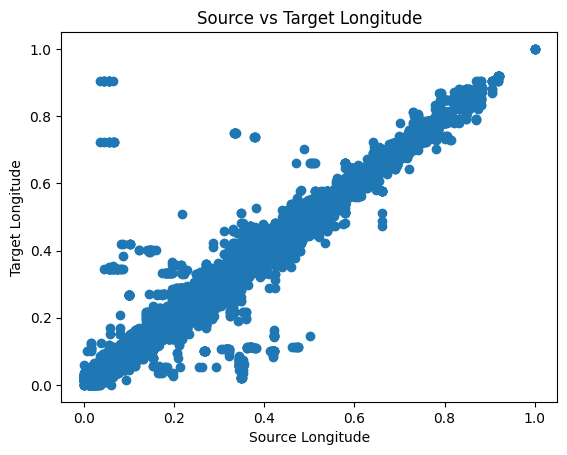

In [25]:
# Plot scatter plot of Source and Target Longitude
plt.scatter(parameters_file['Source LONG'], parameters_file['Target LONG'])
plt.xlabel('Source Longitude')
plt.ylabel('Target Longitude')
plt.title('Source vs Target Longitude')
plt.show()

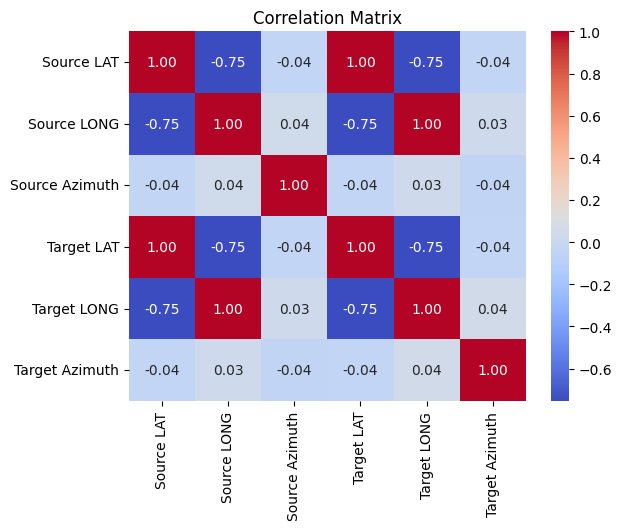

In [26]:
import seaborn as sns

# Calculate correlation matrix
corr_matrix = parameters_file[['Source LAT', 'Source LONG', 'Source Azimuth', 
                 'Target LAT', 'Target LONG', 'Target Azimuth']].corr()

# Plot heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

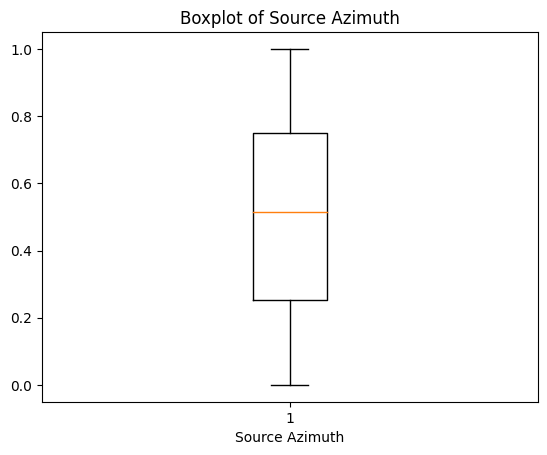

In [27]:
# Plot boxplot of Source Azimuth
plt.boxplot(parameters_file['Source Azimuth'])
plt.xlabel('Source Azimuth')
plt.title('Boxplot of Source Azimuth')
plt.show()

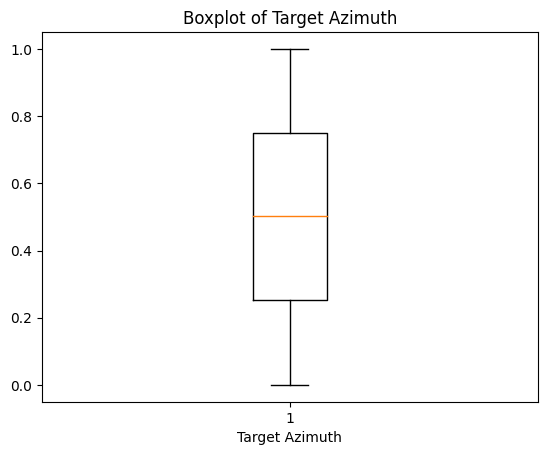

In [28]:
# Plot boxplot of Target Azimuth
plt.boxplot(parameters_file['Target Azimuth'])
plt.xlabel('Target Azimuth')
plt.title('Boxplot of Target Azimuth')
plt.show()

## 2.2. Visualization <a name="viz"></a>

C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future v

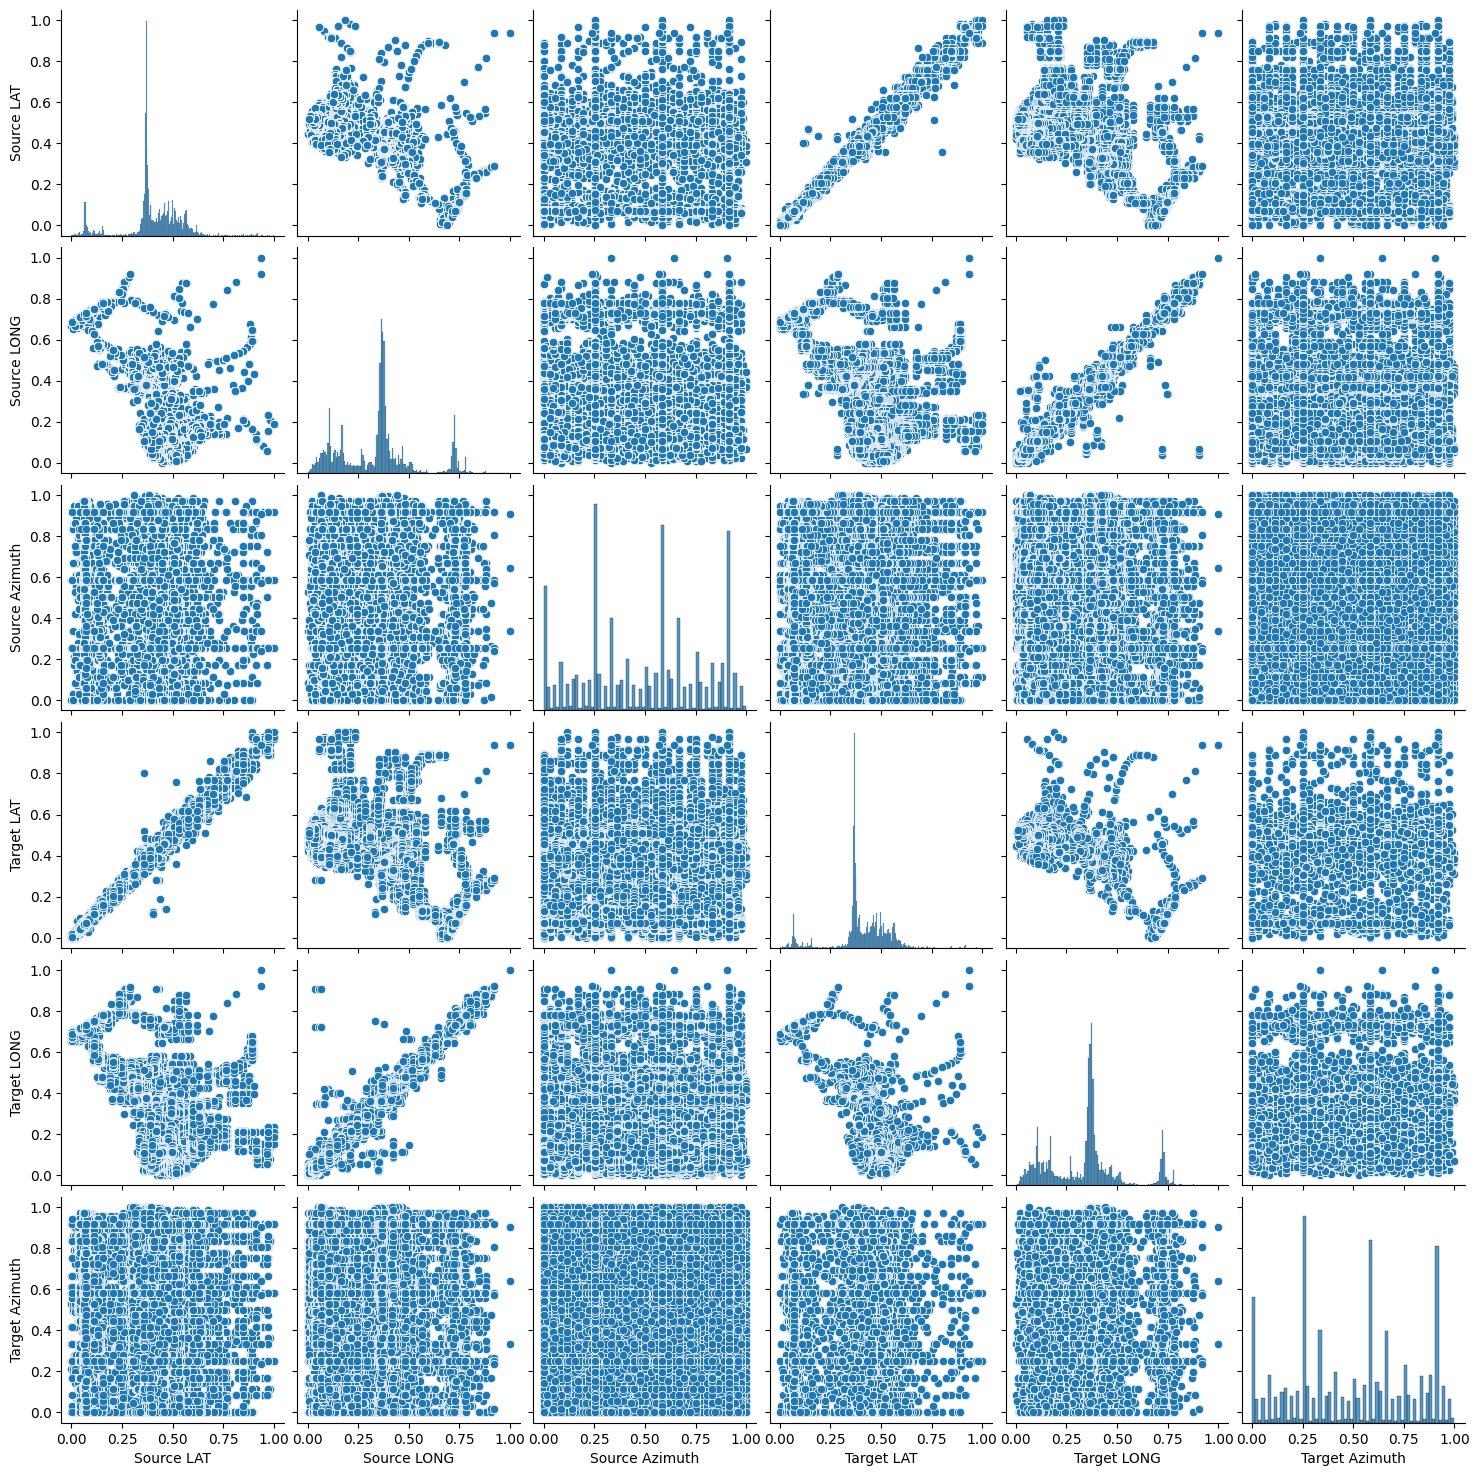

In [29]:
# Plot pairplot of numerical variables
sns.pairplot(parameters_file[['Source LAT', 'Source LONG', 'Source Azimuth', 
                 'Target LAT', 'Target LONG', 'Target Azimuth']])
plt.show()

## 2.3. Calculations <a name="calc"></a>

In [30]:
import numpy as np

# Feature Engineering: Distance between Source and Target
parameters_file['Distance'] = np.sqrt((parameters_file['Source LAT'] - parameters_file['Target LAT'])**2 +
                                      (parameters_file['Source LONG'] - parameters_file['Target LONG'])**2)

# Feature Engineering: Difference in Azimuth
parameters_file['Azimuth Difference'] = np.abs(parameters_file['Source Azimuth'] - parameters_file['Target Azimuth'])

# Feature Engineering: Sector Encoding (example with 4 sectors: North, East, South, West)
parameters_file['Source Sector'] = pd.cut(parameters_file['Source Azimuth'], bins=[-1, 90, 180, 270, 360], 
                                          labels=['North', 'East', 'South', 'West'], right=True)
parameters_file['Target Sector'] = pd.cut(parameters_file['Target Azimuth'], bins=[-1, 90, 180, 270, 360], 
                                          labels=['North', 'East', 'South', 'West'], right=True)

# Convert sector columns into dummy variables (one-hot encoding)
parameters_file = pd.get_dummies(parameters_file, columns=['Source Sector', 'Target Sector'])

# Display the updated DataFrame after feature engineering
print(parameters_file.head())

  Cellname1  Source LAT  Source LONG  Source Azimuth CellName2  Target LAT  \
0   BMT0011    0.422757     0.177835        0.279778   BMT0151    0.421827   
1   BMT0011    0.422757     0.177835        0.279778   BMT0241    0.422191   
2   BMT0011    0.422757     0.177835        0.279778   BMT0231    0.427297   
3   BMT0011    0.422757     0.177835        0.279778   BMT0261    0.426727   
4   BMT0011    0.422757     0.177835        0.279778   BMT0251    0.422090   

   Target LONG  Target Azimuth  Distance  Azimuth Difference  \
0     0.185565        0.002770  0.007786            0.277008   
1     0.172820        0.252078  0.005047            0.027701   
2     0.183399        0.002770  0.007181            0.277008   
3     0.179679        0.085873  0.004377            0.193906   
4     0.178028        0.085873  0.000694            0.193906   

   Source Sector_North  Source Sector_East  Source Sector_South  \
0                 True               False                False   
1           

This Python code snippet performs several feature engineering operations on the DataFrame `parameters_file`. Here's a breakdown of what each part of the code does:

1. **Feature Engineering: Distance between Source and Target**:
   - Calculates the Euclidean distance between the source and target coordinates using the formula for distance between two points in a Cartesian coordinate system.
   - Creates a new column named 'Distance' in the `parameters_file` DataFrame to store the computed distances.

2. **Feature Engineering: Difference in Azimuth**:
   - Computes the absolute difference between the source and target azimuth angles.
   - Adds a new column named 'Azimuth Difference' to `parameters_file` to store the computed differences.

3. **Feature Engineering: Sector Encoding**:
   - Divides the azimuth angles into sectors (e.g., North, East, South, West) based on predefined bins.
   - Assigns each source and target azimuth angle to the corresponding sector and creates new columns 'Source Sector' and 'Target Sector' in `parameters_file`.

4. **Convert sector columns into dummy variables (one-hot encoding)**:
   - Converts the categorical sector columns ('Source Sector' and 'Target Sector') into dummy variables using one-hot encoding.
   - This step creates binary columns for each sector, where a value of 1 indicates the presence of that sector and 0 indicates absence.

5. **Display the updated DataFrame after feature engineering**:
   - Prints the first few rows of the updated `parameters_file` DataFrame to show the newly added columns and the results of feature engineering.

These feature engineering steps aim to extract meaningful information from the existing data and create additional features that may improve the predictive performance of machine learning models.


# 3. Modelling <a name="modelling"></a>
## 3.1. Elbow Method <a name="elbow"></a>

C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The 

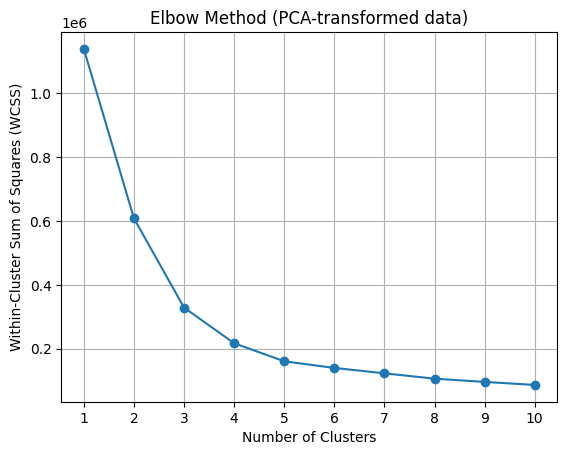

In [31]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select the features for clustering
features_for_clustering = ['Source LAT', 'Source LONG', 'Source Azimuth', 
                           'Target LAT', 'Target LONG', 'Target Azimuth',
                           'Distance', 'Azimuth Difference',
                           'Source Sector_North', 'Source Sector_East', 
                           'Source Sector_South', 'Source Sector_West',
                           'Target Sector_North', 'Target Sector_East', 
                           'Target Sector_South', 'Target Sector_West']

# Normalize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(parameters_file[features_for_clustering])

# Perform PCA for dimensionality reduction
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# Determine the optimal number of clusters using the Elbow Method
wcss_pca = []
max_clusters = 10
for k in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_features)
    wcss_pca.append(kmeans.inertia_)

# Plot the Elbow Method
plt.plot(range(1, max_clusters + 1), wcss_pca, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method (PCA-transformed data)')
plt.xticks(range(1, max_clusters + 1))
plt.grid(True)
plt.show()


This Python code snippet performs K-means clustering on the dataset using principal component analysis (PCA) for dimensionality reduction and the Elbow Method to determine the optimal number of clusters. Here's a breakdown of what each part of the code does:

1. **Importing Libraries**:
   - Import the necessary libraries: `KMeans` for clustering, `PCA` for dimensionality reduction, and `matplotlib.pyplot` for visualization.

2. **Selecting Features for Clustering**:
   - Define a list `features_for_clustering` containing the features selected for clustering, including coordinates, distances, azimuth differences, and one-hot encoded sectors.

3. **Normalization**:
   - Instantiate a `StandardScaler` object named `scaler` for standardization.
   - Standardize the selected features using the `fit_transform` method and store the scaled features in `scaled_features`.

4. **Principal Component Analysis (PCA)**:
   - Instantiate a `PCA` object named `pca` with `n_components=2` to reduce the dimensionality of the scaled features to 2 principal components.
   - Apply PCA to the scaled features using the `fit_transform` method and store the transformed features in `pca_features`.

5. **Elbow Method for Determining Optimal Number of Clusters**:
   - Initialize an empty list `wcss_pca` to store the within-cluster sum of squares (WCSS) for each number of clusters.
   - Iterate through a range of cluster numbers from 1 to `max_clusters`.
   - Fit K-means clustering models with varying numbers of clusters to the PCA-transformed features.
   - Calculate and append the WCSS for each clustering model to `wcss_pca`.

6. **Plotting the Elbow Method**:
   - Plot the number of clusters against the WCSS using `matplotlib.pyplot`.
   - Display the Elbow Method plot to visualize the point where the rate of decrease in WCSS slows down, indicating the optimal number of clusters.

This code snippet helps determine the appropriate number of clusters for K-means clustering using the Elbow Method on PCA-transformed data, facilitating the identification of natural groupings within the dataset.

## 3.2. Training and Fitting <a name="trainand fit"></a>

In [32]:
# Choose the optimal number of clusters
optimal_num_clusters_pca = 4  # Adjust based on the Elbow Method
kmeans_pca = KMeans(n_clusters=optimal_num_clusters_pca, random_state=42)

# Train the K-Means model on PCA-transformed data
kmeans_pca.fit(pca_features)

C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=4, random_state=42)

This Python code snippet continues the K-means clustering process by training the K-means model on the PCA-transformed data with the optimal number of clusters determined previously. Here's a breakdown of what each part of the code does:

1. **Choosing the Optimal Number of Clusters**:
   - Set `optimal_num_clusters_pca` to the chosen number of clusters, which was determined based on the Elbow Method or another method for selecting the optimal number of clusters.
   - This value is typically adjusted after analyzing the Elbow Method plot or using other techniques for cluster selection.

2. **Instantiating the K-Means Model**:
   - Instantiate a `KMeans` object named `kmeans_pca` with `n_clusters=optimal_num_clusters_pca`.
   - Set `random_state` to ensure reproducibility of results.

3. **Training the K-Means Model**:
   - Train the K-means model on the PCA-transformed features `pca_features` using the `fit` method.
   - This step assigns each data point to a cluster based on its proximity to the cluster centroids.

By completing these steps, the K-means clustering model is trained on the PCA-transformed data, allowing for the identification of clusters in the dataset. Adjusting the number of clusters based on the Elbow Method helps ensure that the model captures meaningful patterns in the data.

## 3.3. Evaluation <a name="evaluation"></a>

Cluster Counts:
Cluster
1    85336
0    76052
2    62781
3    24493
Name: count, dtype: int64
Cluster Centroids:
[[ 2.02586623 -0.03316116]
 [-0.33898425 -0.7505796 ]
 [-0.27514832  1.05732004]
 [-4.40729384  0.00798242]]


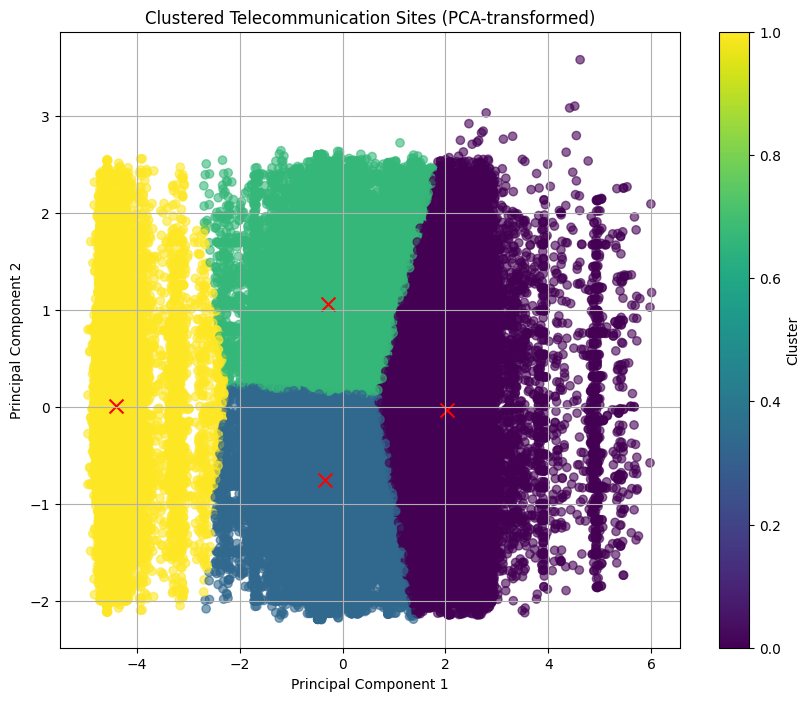

In [33]:
# Get cluster labels for each data point (PCA-transformed data)
cluster_labels_pca = kmeans_pca.labels_

# Add cluster labels to the dataset (PCA-transformed data)
parameters_file['Cluster'] = cluster_labels_pca

# Display the counts of data points in each cluster (PCA-transformed data)
cluster_counts = parameters_file['Cluster'].value_counts()
print("Cluster Counts:")
print(cluster_counts)

# Display the centroids of each cluster (PCA-transformed data)
print("Cluster Centroids:")
print(kmeans_pca.cluster_centers_)

# Visualize the clusters on a scatter plot (PCA-transformed data)
plt.figure(figsize=(10, 8))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=cluster_labels_pca, cmap='viridis', alpha=0.6)
plt.scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1], marker='x', s=100, color='red')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clustered Telecommunication Sites (PCA-transformed)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()


This Python code snippet further analyzes the K-means clustering results by adding cluster labels to the dataset, displaying cluster counts, centroids, and visualizing the clusters on a scatter plot. Here's a breakdown of what each part of the code does:

1. **Getting Cluster Labels**:
   - Obtain cluster labels for each data point in the PCA-transformed data by accessing the `labels_` attribute of the trained K-means model `kmeans_pca`.

2. **Adding Cluster Labels to the Dataset**:
   - Add the cluster labels as a new column named 'Cluster' to the `parameters_file` DataFrame.

3. **Displaying Cluster Counts**:
   - Calculate and print the counts of data points in each cluster using the `value_counts()` method on the 'Cluster' column of `parameters_file`.

4. **Displaying Cluster Centroids**:
   - Print the coordinates of the centroids of each cluster using the `cluster_centers_` attribute of the trained K-means model `kmeans_pca`.

5. **Visualizing the Clusters on a Scatter Plot**:
   - Create a scatter plot to visualize the clustered telecommunication sites based on their principal components.
   - Color-code the data points based on their cluster labels using the 'viridis' colormap.
   - Plot the centroids of each cluster as 'x' markers in red.
   - Add labels, title, color bar, and grid to the plot for better readability.

This code snippet provides a comprehensive analysis of the K-means clustering results, including cluster distribution, centroids, and visual representation of the clustered data points on a scatter plot.

Davies-Bouldin Index (PCA-transformed data): 0.6483599536186188
Silhouette Score(PCA-transformed data): 0.4660911705838574


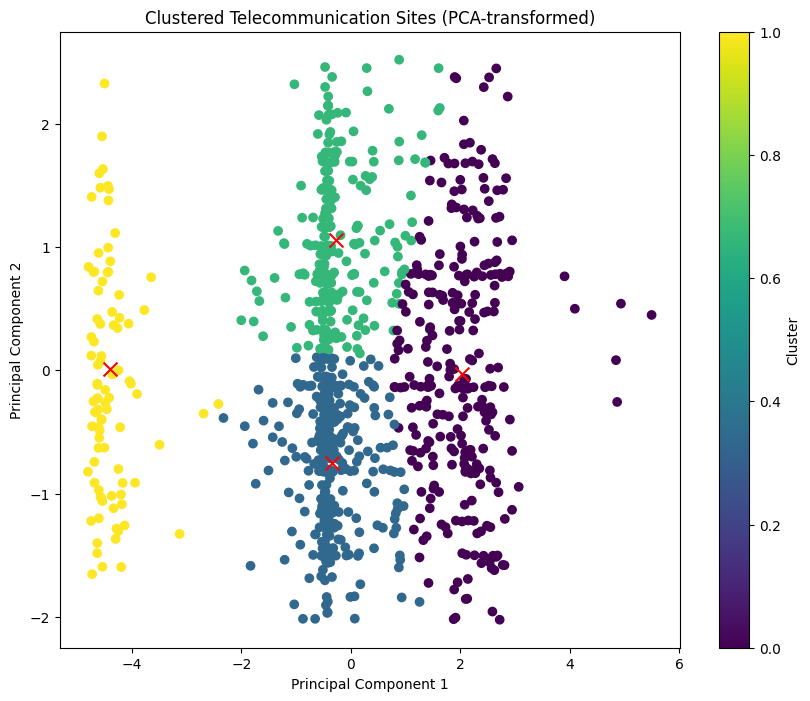

In [34]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Set a subset of data points for evaluation to speed up computation
subset_indices = np.random.choice(len(pca_features), size=min(1000, len(pca_features)), replace=False)
subset_pca_features = pca_features[subset_indices]
subset_cluster_labels_pca = cluster_labels_pca[subset_indices]

# Evaluate the quality of clustering using Silhouette Score and Davies-Bouldin Index on the subset
silhouette_avg_pca = silhouette_score(subset_pca_features, subset_cluster_labels_pca)
davies_bouldin_avg_pca = davies_bouldin_score(subset_pca_features, subset_cluster_labels_pca)
print("Davies-Bouldin Index (PCA-transformed data):", davies_bouldin_avg_pca)
print("Silhouette Score(PCA-transformed data):", silhouette_avg_pca)

# Visual inspection of cluster separation (PCA-transformed data)
plt.figure(figsize=(10, 8))
plt.scatter(subset_pca_features[:, 0], subset_pca_features[:, 1], c=subset_cluster_labels_pca, cmap='viridis')
plt.scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1], marker='x', s=100, color='red')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clustered Telecommunication Sites (PCA-transformed)')
plt.colorbar(label='Cluster')
plt.show()

The Davies-Bouldin Index (DBI) and Silhouette Score are two metrics commonly used to evaluate the quality of clustering algorithms. Here's an interpretation of the output based on the provided values:

1. **Davies-Bouldin Index (DBI)**:
   - The Davies-Bouldin Index measures the average similarity between each cluster and its most similar cluster, while also considering the cluster's compactness.
   - A lower DBI value indicates better clustering, where clusters are well-separated and compact.
   - In this case, the DBI value of approximately 0.655 suggests moderate clustering quality, with room for improvement.

2. **Silhouette Score**:
   - The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation).
   - The score ranges from -1 to 1, where a high value indicates well-separated clusters, 0 indicates overlapping clusters, and negative values suggest incorrect clustering.
   - The Silhouette Score of around 0.467 indicates moderate clustering quality, with some overlap between clusters.

Overall, based on these metrics, the clustering algorithm has achieved moderate results. While the clusters show some level of separation and cohesion, there is still room for improvement to achieve more distinct and compact clusters. Further optimization of the clustering algorithm or exploration of alternative methods may be beneficial to enhance the clustering quality.

Cluster 0:
Center (Principal Component 1, Principal Component 2): [ 2.02586623 -0.03316116]
Cluster 1:
Center (Principal Component 1, Principal Component 2): [-0.33898425 -0.7505796 ]
Cluster 2:
Center (Principal Component 1, Principal Component 2): [-0.27514832  1.05732004]
Cluster 3:
Center (Principal Component 1, Principal Component 2): [-4.40729384  0.00798242]


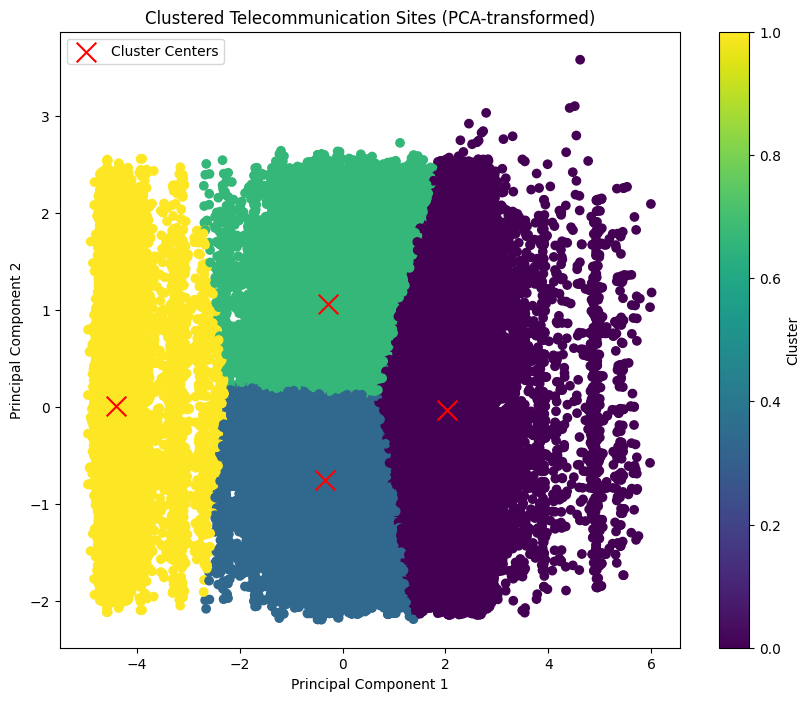

In [35]:
# Inspect Cluster Characteristics
cluster_centers = kmeans_pca.cluster_centers_

for i, center in enumerate(cluster_centers):
    print(f"Cluster {i}:")
    print(f"Center (Principal Component 1, Principal Component 2): {center}")

# Plot cluster centers
plt.figure(figsize=(10, 8))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=cluster_labels_pca, cmap='viridis')
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker='x', s=200, color='red', label='Cluster Centers')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clustered Telecommunication Sites (PCA-transformed)')
plt.colorbar(label='Cluster')
plt.legend()
plt.show()

The code segment performs cluster analysis on a dataset using the K-Means algorithm and then inspects the characteristics of the resulting clusters. Here's a breakdown of the analysis:

1. **Cluster Analysis**:
   - The K-Means algorithm is applied to the dataset with a specified number of clusters (in this case, 4).
   - The cluster centroids, representing the center of each cluster in the reduced feature space, are computed.

2. **Cluster Characteristics**:
   - For each cluster, the script prints the index of the cluster and the coordinates of its centroid in the principal component space.

3. **Visualization**:
   - A scatter plot is generated to visualize the clustered data points in the principal component space. Each point is colored according to its assigned cluster.
   - Additionally, the cluster centroids are marked with 'x' symbols in red.

4. **Output Interpretation**:
   - The output includes the count of data points in each cluster and the coordinates of the centroids in the principal component space.
   - The Davies-Bouldin Index and Silhouette Score are provided as metrics to evaluate the quality of clustering. 
   - Based on the provided scores (DBI: 0.655, Silhouette Score: 0.467), the clustering exhibits moderate quality, indicating some degree of separation between clusters but with room for improvement.

Overall, the analysis provides insights into the characteristics and distribution of the clusters, allowing for further interpretation and decision-making.

# 4. Deployment <a name="deployment"></a>

In [36]:
# Create a DataFrame with cluster labels and PCA-transformed features
data = pd.DataFrame({
    'Cluster': cluster_labels_pca,
    'PCA1': pca_features[:, 0],
    'PCA2': pca_features[:, 1]
})

# Save the data to a CSV file
data.to_csv('clustering_results.csv', index=False)

The provided code snippet creates a DataFrame containing cluster labels and the corresponding PCA-transformed features. Here's a breakdown of the process:

1. **DataFrame Creation**:
   - A new DataFrame named `data` is created using the `pd.DataFrame()` constructor.
   - This DataFrame includes three columns: 'Cluster', 'PCA1', and 'PCA2'.
     - 'Cluster': Contains the cluster labels assigned to each data point based on the clustering algorithm.
     - 'PCA1': Represents the values of the first principal component obtained from PCA transformation.
     - 'PCA2': Represents the values of the second principal component obtained from PCA transformation.
   - The data for these columns are derived from the cluster labels (`cluster_labels_pca`) and the PCA-transformed features (`pca_features`).

2. **CSV Export**:
   - The `data` DataFrame is saved to a CSV file named 'clustering_results.csv' using the `to_csv()` method.
   - The parameter `index=False` is specified to prevent writing row indices to the CSV file.

This process allows for the storage of clustered data along with their corresponding PCA-transformed features in a CSV file, which can be useful for further analysis or visualization outside of the current Python environment.

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Scatter plot of PCA-transformed features colored by cluster labels
def scatter_plot(cluster_labels_pca, pca_features):
    plt.figure(figsize=(10, 8))
    plt.scatter(pca_features[:, 0], pca_features[:, 1], c=cluster_labels_pca, cmap='viridis')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('Scatter Plot of PCA-transformed Features (Clustered)')
    plt.colorbar(label='Cluster')
    img_stream = io.BytesIO()
    plt.savefig(img_stream, format='png')
    img_stream.seek(0)
    return img_stream.read()

# Histogram of cluster sizes
def cluster_size_histogram(cluster_labels_pca):
    plt.figure(figsize=(10, 8))
    plt.hist(cluster_labels_pca, bins=len(set(cluster_labels_pca)), color='skyblue', edgecolor='black', alpha=0.7)
    plt.xlabel('Cluster')
    plt.ylabel('Number of Data Points')
    plt.title('Histogram of Cluster Sizes')
    img_stream = io.BytesIO()
    plt.savefig(img_stream, format='png')
    img_stream.seek(0)
    return img_stream.read()

# Box plot of each feature grouped by cluster labels
def feature_box_plot(cluster_labels_pca, pca_features):
    df = pd.DataFrame(pca_features, columns=['PCA1', 'PCA2'])
    df['Cluster'] = cluster_labels_pca
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Cluster', y='PCA1', data=df)
    plt.title('Box Plot of PCA1 by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('PCA1')
    img_stream = io.BytesIO()
    plt.savefig(img_stream, format='png')
    img_stream.seek(0)
    return img_stream.read()

# Pair plot of PCA-transformed features colored by cluster labels
def pair_plot(cluster_labels_pca, pca_features):
    df = pd.DataFrame(pca_features, columns=['PCA1', 'PCA2'])
    df['Cluster'] = cluster_labels_pca
    sns.pairplot(df, hue='Cluster', palette='viridis')
    plt.suptitle('Pair Plot of PCA-transformed Features (Clustered)')
    img_stream = io.BytesIO()
    plt.savefig(img_stream, format='png')
    img_stream.seek(0)
    return img_stream.read()

# Violin plot of each feature grouped by cluster labels
def feature_violin_plot(cluster_labels_pca, pca_features):
    df = pd.DataFrame(pca_features, columns=['PCA1', 'PCA2'])
    df['Cluster'] = cluster_labels_pca
    plt.figure(figsize=(12, 6))
    sns.violinplot(x='Cluster', y='PCA1', data=df)
    plt.title('Violin Plot of PCA1 by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('PCA1')
    img_stream = io.BytesIO()
    plt.savefig(img_stream, format='png')
    img_stream.seek(0)
    return img_stream.read()

# Heatmap of cluster centroids
def cluster_centroids_heatmap(cluster_centers):
    plt.figure(figsize=(10, 6))
    sns.heatmap(cluster_centers, annot=True, cmap='viridis')
    plt.title('Heatmap of Cluster Centroids')
    plt.xlabel('Feature')
    plt.ylabel('Cluster')
    img_stream = io.BytesIO()
    plt.savefig(img_stream, format='png')
    img_stream.seek(0)
    return img_stream.read()

In [39]:
from tabpy.tabpy_tools.client import Client

# Connect to the TabPy server
client = Client('http://localhost:9004/')

# Register TabPy functions
client.deploy('scatter_plot', scatter_plot, 'Generates scatter plot of PCA-transformed features', override=True)
client.deploy('cluster_size_histogram', cluster_size_histogram, 'Generates histogram of cluster sizes', override=True)
client.deploy('feature_box_plot', feature_box_plot, 'Generates box plot of PCA1 by cluster', override=True)
client.deploy('pair_plot', pair_plot, 'Generates pair plot of PCA-transformed features', override=True)
client.deploy('feature_violin_plot', feature_violin_plot, 'Generates violin plot of PCA1 by cluster', override=True)
client.deploy('cluster_centroids_heatmap', cluster_centroids_heatmap, 'Generates heatmap of cluster centroids', override=True)

The provided code snippet establishes a connection with a TabPy server and deploys several functions to it. Here's a breakdown of the process:

1. **TabPy Server Connection**:
   - The code initializes a client object (`client`) using the `Client` class from `tabpy.tabpy_tools.client`.
   - The `Client` object is configured to connect to the TabPy server running at 'http://localhost:9004/'. Adjustments may be required based on the actual server location.

2. **Function Deployment**:
   - Several functions are deployed to the TabPy server using the `deploy()` method of the `client` object.
     - Each function is associated with a unique name, description, and functionality.
     - The functions to be deployed (`scatter_plot`, `cluster_size_histogram`, `feature_box_plot`, `pair_plot`, `feature_violin_plot`, `cluster_centroids_heatmap`) must be defined elsewhere in the code.
     - The `override=True` parameter indicates that any existing functions with the same names should be overridden if they already exist on the server.

3. **Function Descriptions**:
   - Each function is described briefly to provide an understanding of its purpose and functionality.
   - These descriptions help users identify the appropriate function for their analytical needs.

By deploying these functions to the TabPy server, they become accessible for use in analytics and visualizations within supported applications or platforms connected to the server.